In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

"""
Al ser utilidades locales del repositorio
se deben realizar la importación luego
del sys.path()
"""
from utils import eda_utils, vis_descriptiva

In [2]:
data = pd.read_csv("../dataset/Spotify_crudo.csv")

df = data.copy()

In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [5]:
df = df.drop(columns=["Unnamed: 0", "track_id"])

In [6]:
outliers_iqr = eda_utils.detectar_outliers_iqr(df)
outliers_3sig = eda_utils.detectar_outliers_3sigmas(df)

In [7]:
df.describe(include="object") 

C:\Users\aarav\AppData\Local\Temp\ipykernel_19936\3113323196.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,artists,album_name,track_name,track_genre
count,113999,113999,113999,114000
unique,31437,46589,73608,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,279,195,151,1000


In [8]:
print("***Detección de outliers con método IQR***", end="\n" + ("-"*40) + "\n")

total_outliers_iqr = 0

outliers_iqr = eda_utils.detectar_outliers_iqr(df)
for col, info in outliers_iqr.items():
    total_outliers_iqr += info["cantidad_outliers"]

    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

print(f"TOTAL DE OUTLIERS IDENTIFICADOS: {total_outliers_iqr}")

***Detección de outliers con método IQR***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.046
Cantidad de outliers: 2
Límite inferior: -32.500
Límite superior: 99.500
----------------------------------------
Columna: duration_ms
Asimetría (skew): 11.195
Cantidad de outliers: 5617
Límite inferior: 42906.000
Límite superior: 392666.000
----------------------------------------
Columna: danceability
Asimetría (skew): -0.399
Cantidad de outliers: 620
Límite inferior: 0.098
Límite superior: 1.053
----------------------------------------
Columna: energy
Asimetría (skew): -0.597
Cantidad de outliers: 0
Límite inferior: -0.101
Límite superior: 1.427
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -7.000
Límite superior: 17.000
----------------------------------------
Columna: loudness
Asimetría (skew): -2.007
Cantidad de outliers: 6173
Límite inferior: -17.528
Límite superior: 2.512
-------

In [9]:
df.isna().sum()

artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
print(df.duplicated().sum())

577


In [12]:
duplicados = df[df.duplicated(keep=False)]

In [13]:
duplicados

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1874,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
1925,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2044,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.060100,0.000000,0.3070,0.662,120.041,4,alt-rock
2046,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.060100,0.000000,0.3070,0.662,120.041,4,alt-rock
2082,The Smashing Pumpkins,Alternative Christmas 2022,Christmastime,0,196723,False,0.165,0.434,0,-8.163,1,0.0288,0.316000,0.171000,0.2130,0.186,77.983,3,alt-rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112968,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish
113295,Matt Redman,Sing Like Never Before: The Essential Collection,Our God - New Recording,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.384,105.021,4,world-music
113345,Matt Redman,Sing Like Never Before: The Essential Collection,Our God - New Recording,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.384,105.021,4,world-music
113881,Bryan & Katie Torwalt,I've Got Good News (Live) [Deluxe],Good News - Live,23,266632,False,0.473,0.474,6,-9.175,1,0.0558,0.395000,0.000000,0.1630,0.251,140.746,4,world-music


In [14]:
df = df.drop_duplicates()

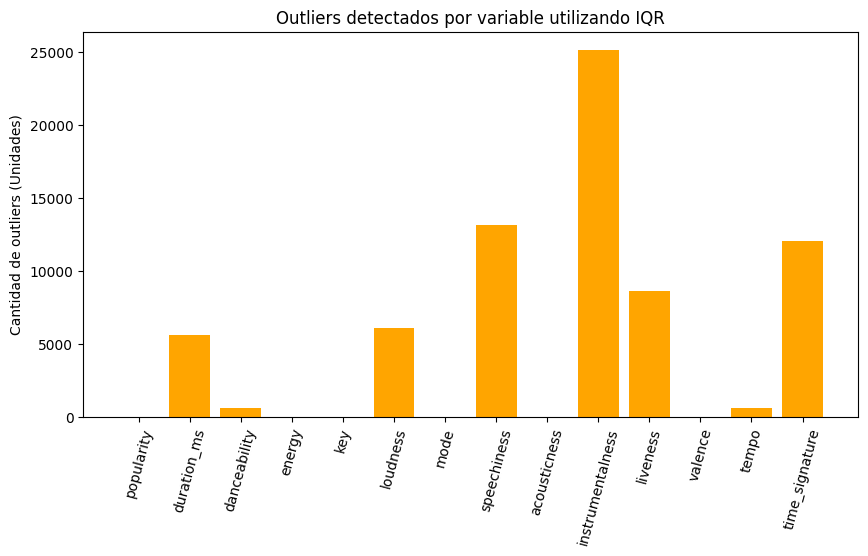

In [15]:
resultados = eda_utils.detectar_outliers_iqr(df)

outliers = {
    col: datos['cantidad_outliers']
    for col, datos in resultados.items()
}

plt.figure(figsize=(10,5))

plt.bar(
    outliers.keys(),
    outliers.values(),
        color = "orange"
)

plt.xticks(rotation=75)

plt.ylabel("Cantidad de outliers (Unidades)")
plt.title("Outliers detectados por variable utilizando IQR")

plt.show()

In [16]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113422.000000,1.134220e+05,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000
mean,33.359674,2.281011e+05,0.567113,0.642174,5.309332,-8.242913,0.637681,0.084697,0.314075,0.155802,0.213610,0.474239,122.176181,3.904225
std,22.269626,1.064508e+05,0.173402,0.251031,3.559767,5.011931,0.480673,0.105803,0.331943,0.309314,0.190481,0.259239,29.972104,0.432077
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741700e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.299000,4.000000
50%,35.000000,2.130160e+05,0.580000,0.685000,5.000000,-6.996000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.019000,4.000000
75%,50.000000,2.616000e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084575,0.596000,0.048700,0.273000,0.683000,140.073000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [17]:
df_wins = eda_utils.winsorizar_iqr(df)

df_wins.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73.0,230666,False,0.676,0.4610,1,-6.7460,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610,False,0.420,0.1660,1,-17.2350,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826,False,0.438,0.3590,0,-9.7340,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933,False,0.266,0.0596,0,-17.4935,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,4,acoustic
4,Chord Overstreet,Hold On,Hold On,82.0,198853,False,0.618,0.4430,2,-9.6810,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [18]:
print("***Detección de outliers con método IQR***", end="\n" + ("-"*40) + "\n")

total_outliers_iqr = 0

outliers_iqr = eda_utils.detectar_outliers_iqr(df_wins)
for col, info in outliers_iqr.items():
    total_outliers_iqr += info["cantidad_outliers"]

    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

print(f"TOTAL DE OUTLIERS IDENTIFICADOS: {total_outliers_iqr}")

***Detección de outliers con método IQR***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.041
Cantidad de outliers: 0
Límite inferior: -32.500
Límite superior: 99.500
----------------------------------------
Columna: duration_ms
Asimetría (skew): 0.499
Cantidad de outliers: 0
Límite inferior: 43025.000
Límite superior: 392745.000
----------------------------------------
Columna: danceability
Asimetría (skew): -0.377
Cantidad de outliers: 0
Límite inferior: 0.098
Límite superior: 1.053
----------------------------------------
Columna: energy
Asimetría (skew): -0.599
Cantidad de outliers: 0
Límite inferior: -0.099
Límite superior: 1.425
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -7.000
Límite superior: 17.000
----------------------------------------
Columna: loudness
Asimetría (skew): -0.869
Cantidad de outliers: 0
Límite inferior: -17.493
Límite superior: 2.494
----------------

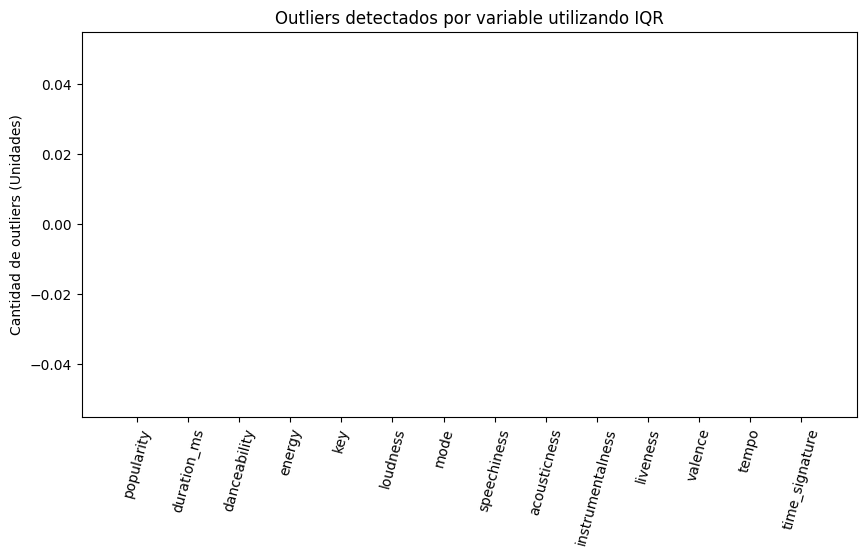

In [19]:
resultados = eda_utils.detectar_outliers_iqr(df_wins)

outliers = {
    col: datos['cantidad_outliers']
    for col, datos in resultados.items()
}

plt.figure(figsize=(10,5))

plt.bar(
    outliers.keys(),
    outliers.values(),
        color = "orange"
)

plt.xticks(rotation=75)

plt.ylabel("Cantidad de outliers (Unidades)")
plt.title("Outliers detectados por variable utilizando IQR")

plt.show()



Variable target *popularity*

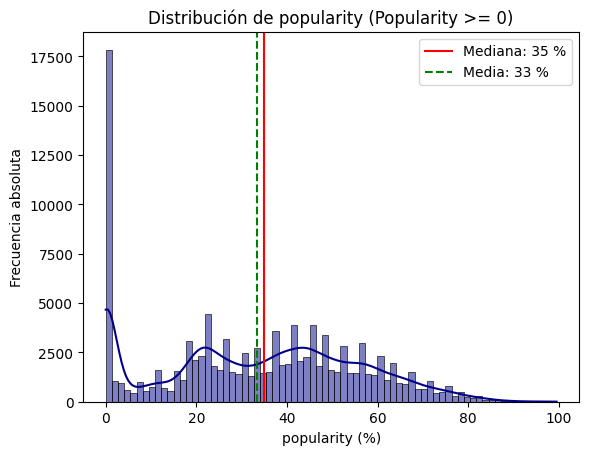

In [20]:
sns.histplot(
    data = df_wins,
    x = 'popularity',
    kde = True,
    color="darkblue"
)

plt.axvline(df_wins['popularity'].median(), label = f'Mediana: {df_wins['popularity'].median():.0f} %', color = 'red')
plt.axvline(df_wins['popularity'].mean(), label = f'Media: {df_wins['popularity'].mean():.0f} %', color = 'green', linestyle = '--')
plt.title('Distribución de popularity (Popularity >= 0)')
plt.xlabel('popularity (%)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.show()

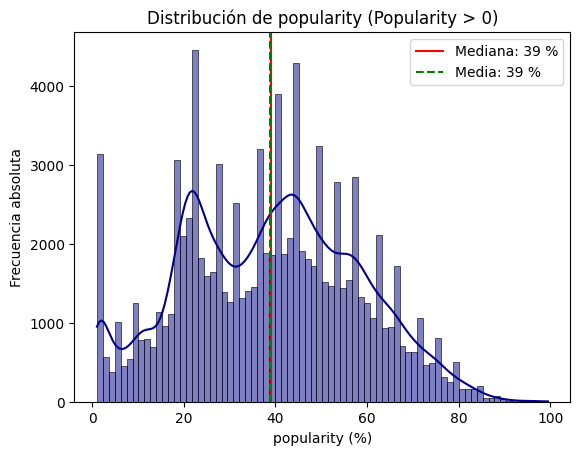

In [21]:
df_filtered = df_wins[df_wins['popularity'] > 0]

sns.histplot(
    data=df_filtered,
    x='popularity',
    kde=True,
    color="darkblue"
)

mediana = df_filtered['popularity'].median()
media = df_filtered['popularity'].mean()


plt.axvline(mediana, label=f"Mediana: {mediana:.0f} %", color='red')
plt.axvline(media, label=f"Media: {media:.0f} %", color='green', linestyle='--')

plt.title('Distribución de popularity (Popularity > 0)')
plt.xlabel('popularity (%)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.show()

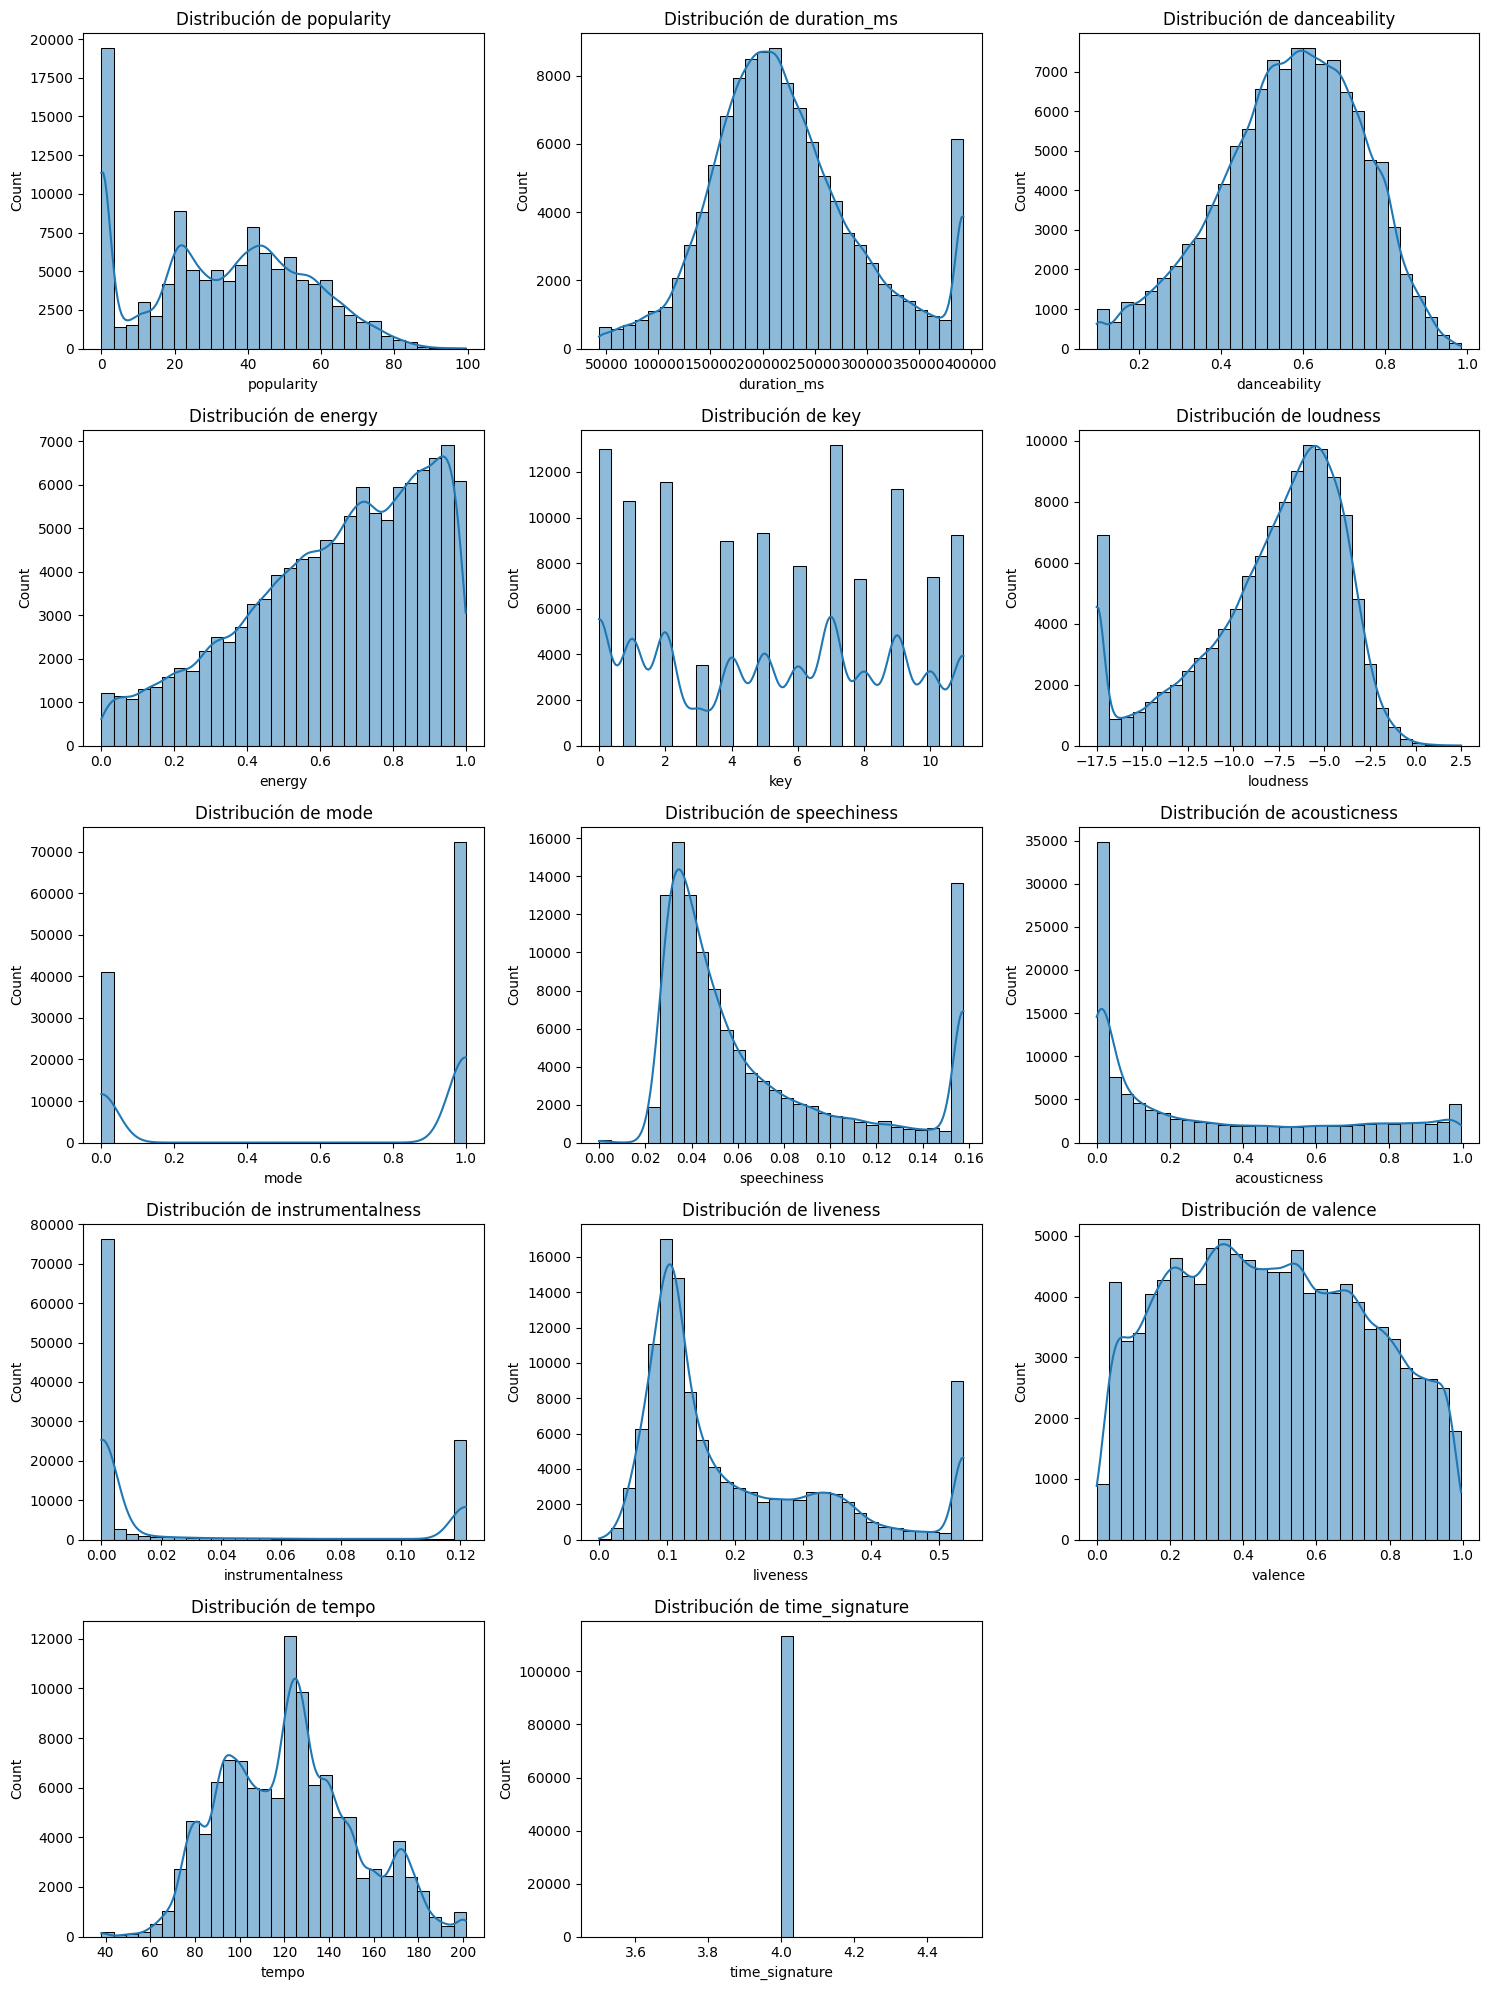

In [22]:
vis_descriptiva.graficar_distribuciones_numericas(df_wins)

In [23]:
df_wins.to_excel("Spotify_Winsorizado.xlsx", index=False)